<a href="https://colab.research.google.com/github/SeveroCWB/portifolio/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Visão Computacional Redução de Dimensionalidade***

1. Importe uma imagem;
2. Converta em escala de cinza;
3. Mostre as dimensões (pixels);
4. Converta para o formato padrão da ferramenta de simulação;
5. Aplique a função PCA para obter os parâmetros adequados;
6. Ajuste a redução das características para 95 e 99 % da variância explicada;
7. Mostre a imagem original e a imagem reconstruída após as respectivas reduções;
8. Mostre a quantidade de características da imagem original e das imagens reconstruídas;
9. Mostre o gráfico das projeções das observações e dos autovetores.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from PIL import Image
import requests
from io import BytesIO


# **1. Importe uma imagem;**

In [2]:
print("1. IMPORTANDO IMAGEM...")

# URL da imagem
url = "https://ikebana.agenciamango.com.br/wp-content/uploads/2019/07/descubra-como-cultivar-girassol-uma-das-flores-mais-lindas-do-mundo-1-1536x1020.jpeg"

# Baixar e abrir a imagem
response = requests.get(url)
img = Image.open(BytesIO(response.content))

print("Imagem original carregada com sucesso!")

1. IMPORTANDO IMAGEM...
Imagem original carregada com sucesso!


# **2. Converta em escala de cinza;**

In [3]:
print("\n2. CONVERTENDO PARA ESCALA DE CINZA...")

img_gray = img.convert('L')  # 'L' mode for grayscale

print("Conversão para escala de cinza concluída!")


2. CONVERTENDO PARA ESCALA DE CINZA...
Conversão para escala de cinza concluída!


# **3. Mostre as dimensões (pixels);**

In [5]:
print("\n3. DIMENSÕES DA IMAGEM:")

print(f"Dimensões originais: {img.size}")  # (largura, altura)
print(f"Dimensões em escala de cinza: {img_gray.size}")


3. DIMENSÕES DA IMAGEM:
Dimensões originais: (1536, 1020)
Dimensões em escala de cinza: (1536, 1020)


# **4. Converta para o formato padrão da ferramenta de simulação;**

In [6]:
print("\n4. CONVERTENDO PARA FORMATO PADRÃO...")

# Converter para array numpy
img_array = np.array(img_gray)

print(f"Formato do array: {img_array.shape}")
print(f"Tipo dos dados: {img_array.dtype}")



4. CONVERTENDO PARA FORMATO PADRÃO...
Formato do array: (1020, 1536)
Tipo dos dados: uint8


# **5. Aplique a função PCA para obter os parâmetros adequados;**

In [7]:
print("\n5. APLICANDO PCA...")

# Achatar a imagem para 2D (amostras x características)
height, width = img_array.shape
features_original = img_array.reshape(height, width)

# Padronizar os dados
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_original)

# Criar objeto PCA
pca_full = PCA()
features_pca_full = pca_full.fit_transform(features_scaled)

print("PCA aplicado com sucesso!")
print(f"Número total de componentes possíveis: {pca_full.n_components_}")


5. APLICANDO PCA...
PCA aplicado com sucesso!
Número total de componentes possíveis: 1020


# **6. Ajuste a redução das características para 95 e 99 % da variância explicada;**

In [8]:
print("\n6. REDUZINDO DIMENSIONALIDADE...")

# PCA com 95% de variância
pca_95 = PCA(n_components=0.95, whiten=True)
features_pca_95 = pca_95.fit_transform(features_scaled)

# PCA com 99% de variância
pca_99 = PCA(n_components=0.99, whiten=True)
features_pca_99 = pca_99.fit_transform(features_scaled)

print("Redução de dimensionalidade concluída!")



6. REDUZINDO DIMENSIONALIDADE...
Redução de dimensionalidade concluída!


# **7. Mostre a imagem original e a imagem reconstruída após as respectivas reduções;**


7. RECONSTRUINDO IMAGENS...


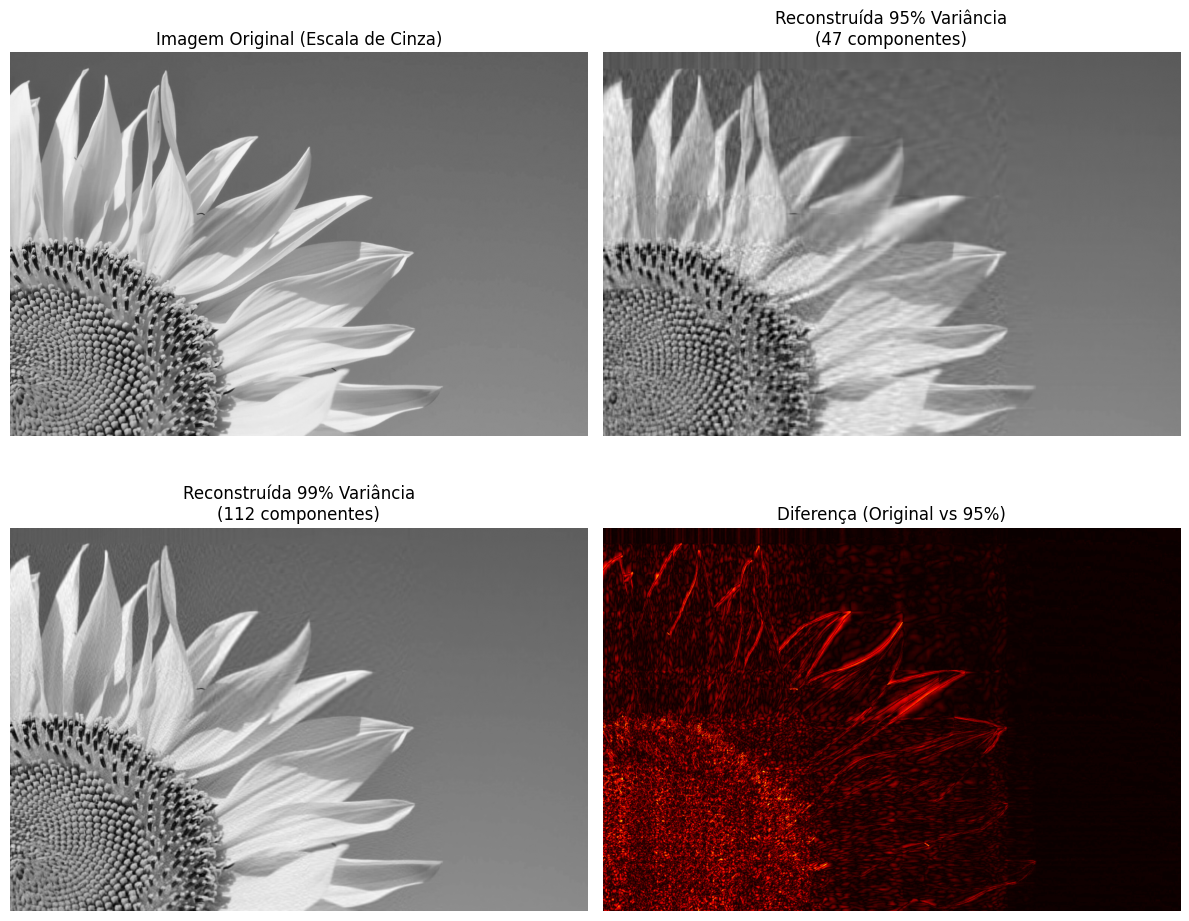

In [9]:
print("\n7. RECONSTRUINDO IMAGENS...")

# Reconstruir imagens a partir dos componentes
img_reconstructed_95 = pca_95.inverse_transform(features_pca_95)
img_reconstructed_99 = pca_99.inverse_transform(features_pca_99)

# Des-padronizar as imagens reconstruídas
img_reconstructed_95 = scaler.inverse_transform(img_reconstructed_95)
img_reconstructed_99 = scaler.inverse_transform(img_reconstructed_99)

# Garantir que os valores estejam no range correto
img_reconstructed_95 = np.clip(img_reconstructed_95, 0, 255).astype(np.uint8)
img_reconstructed_99 = np.clip(img_reconstructed_99, 0, 255).astype(np.uint8)

# Plotar as imagens
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Imagem original
axes[0, 0].imshow(img_array, cmap='gray')
axes[0, 0].set_title('Imagem Original (Escala de Cinza)')
axes[0, 0].axis('off')

# Imagem reconstruída 95%
axes[0, 1].imshow(img_reconstructed_95, cmap='gray')
axes[0, 1].set_title(f'Reconstruída 95% Variância\n({pca_95.n_components_} componentes)')
axes[0, 1].axis('off')

# Imagem reconstruída 99%
axes[1, 0].imshow(img_reconstructed_99, cmap='gray')
axes[1, 0].set_title(f'Reconstruída 99% Variância\n({pca_99.n_components_} componentes)')
axes[1, 0].axis('off')

# Diferença entre original e 95%
difference = np.abs(img_array.astype(float) - img_reconstructed_95.astype(float))
axes[1, 1].imshow(difference, cmap='hot')
axes[1, 1].set_title('Diferença (Original vs 95%)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# **8. Mostre a quantidade de características da imagem original e das imagens reconstruídas;**

In [10]:
print("\n8. COMPARAÇÃO DE CARACTERÍSTICAS:")

print(f"Quantidade de características originais: {width}")
print(f"Quantidade após redução para 95% variância: {pca_95.n_components_}")
print(f"Quantidade após redução para 99% variância: {pca_99.n_components_}")

# Calcular taxa de compressão
compression_95 = (1 - pca_95.n_components_ / width) * 100
compression_99 = (1 - pca_99.n_components_ / width) * 100

print(f"\nTaxa de compressão (95% variância): {compression_95:.2f}%")
print(f"Taxa de compressão (99% variância): {compression_99:.2f}%")


8. COMPARAÇÃO DE CARACTERÍSTICAS:
Quantidade de características originais: 1536
Quantidade após redução para 95% variância: 47
Quantidade após redução para 99% variância: 112

Taxa de compressão (95% variância): 96.94%
Taxa de compressão (99% variância): 92.71%


# **9. Mostre o gráfico das projeções das observações e dos autovetores.**


9. GERANDO GRÁFICOS DE ANÁLISE...


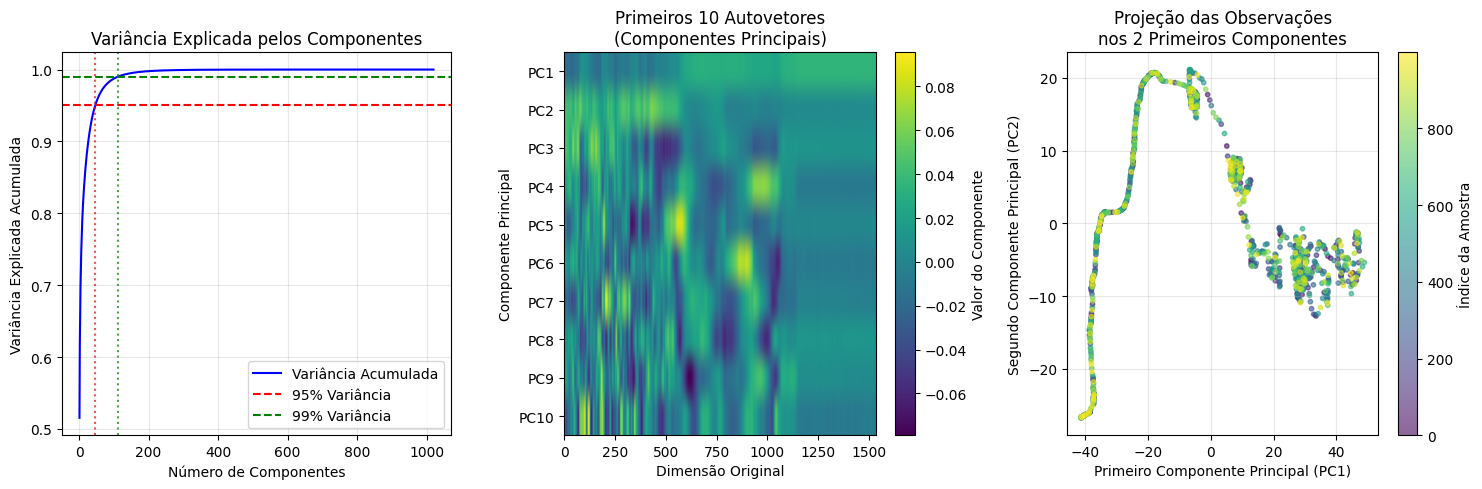

In [11]:
print("\n9. GERANDO GRÁFICOS DE ANÁLISE...")

# Gráfico da variância acumulada
plt.figure(figsize=(15, 5))

# Subplot 1: Variância explicada
plt.subplot(1, 3, 1)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', label='Variância Acumulada')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variância')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variância')
plt.axvline(x=pca_95.n_components_, color='r', linestyle=':', alpha=0.7)
plt.axvline(x=pca_99.n_components_, color='g', linestyle=':', alpha=0.7)

plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada pelos Componentes')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Primeiros componentes principais (autovetores)
plt.subplot(1, 3, 2)
n_components_to_plot = min(10, pca_full.n_components_)
components = pca_full.components_[:n_components_to_plot]

plt.imshow(components, cmap='viridis', aspect='auto')
plt.colorbar(label='Valor do Componente')
plt.xlabel('Dimensão Original')
plt.ylabel('Componente Principal')
plt.title(f'Primeiros {n_components_to_plot} Autovetores\n(Componentes Principais)')
plt.yticks(range(n_components_to_plot), [f'PC{i+1}' for i in range(n_components_to_plot)])

# Subplot 3: Projeções das observações nos dois primeiros componentes
plt.subplot(1, 3, 3)
if features_pca_full.shape[1] >= 2:
    # Amostrar pontos para não sobrecarregar o gráfico
    sample_indices = np.random.choice(features_pca_full.shape[0], size=min(1000, features_pca_full.shape[0]), replace=False)

    plt.scatter(features_pca_full[sample_indices, 0], features_pca_full[sample_indices, 1],
               alpha=0.6, s=10, c=range(len(sample_indices)), cmap='viridis')
    plt.xlabel('Primeiro Componente Principal (PC1)')
    plt.ylabel('Segundo Componente Principal (PC2)')
    plt.title('Projeção das Observações\nnos 2 Primeiros Componentes')
    plt.colorbar(label='Índice da Amostra')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Dados insuficientes\npara projeção 2D',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Projeção das Observações')

plt.tight_layout()
plt.show()